# ESCI Dataset Exploratory Analysis

This notebook performs focused EDA on the ESCI shopping queries dataset to help design LLM prompts. It computes character-length statistics for query and product fields and visualizes their distributions. Run cells top-to-bottom.

In [7]:
# Imports and basic setup
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = os.path.join('/Users/aaronallen/Desktop/grainger_project/esci-data','shopping_queries_dataset')
examples_path = os.path.join(DATA_DIR, 'shopping_queries_dataset_examples.parquet')
products_path = os.path.join(DATA_DIR, 'shopping_queries_dataset_products.parquet')
sources_path = os.path.join(DATA_DIR, 'shopping_queries_dataset_sources.csv')

In [6]:
# Load data (skip if files are not present)
df_examples = pd.read_parquet(examples_path)
df_products = pd.read_parquet(products_path)
df_sources = pd.read_csv(sources_path)

print('Loaded:', len(df_examples), 'examples and', len(df_products), 'products')

Loaded: 2621288 examples and 1814924 products


In [47]:
# Merge and preview
df = pd.merge(df_examples, df_products, how='left', left_on=['product_locale','product_id'], right_on=['product_locale','product_id'])

print('Merged dataframe shape:', df.shape)
df.head()

Merged dataframe shape: (2621288, 14)


,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split,product_title,product_description,product_bullet_point,product_brand,product_color
0,0,revent 80 cfm,0,B000MOO21W,us,I,0,1,train,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceil...,None,WhisperCeiling fans feature a totally enclosed...,Panasonic,White
1,1,revent 80 cfm,0,B07X3Y6B1V,us,E,0,1,train,Homewerks 7141-80 Bathroom Fan Integrated LED ...,None,OUTSTANDING PERFORMANCE: This Homewerk's bath ...,Homewerks,80 CFM
2,2,revent 80 cfm,0,B07WDM7MQQ,us,E,0,1,train,Homewerks 7140-80 Bathroom Fan Ceiling Mount E...,None,OUTSTANDING PERFORMANCE: This Homewerk's bath ...,Homewerks,White
3,3,revent 80 cfm,0,B07RH6Z8KW,us,E,0,1,train,Delta Electronics RAD80L BreezRadiance 80 CFM ...,This pre-owned or refurbished product has been...,Quiet operation at 1.5 sones\nBuilt-in thermos...,DELTA ELECTRONICS (AMERICAS) LTD.,White
4,4,revent 80 cfm,0,B07QJ7WYFQ,us,E,0,1,train,Panasonic FV-08VRE2 Ventilation Fan with Reces...,None,The design solution for Fan/light combinations...,Panasonic,White


In [48]:
df["full_product_context"] = df.apply(lambda row: ' '.join([str(row[field]) for field in ["product_title", "product_bullet_point", "product_description", "product_brand", "product_color"] if pd.notnull(row[field])]), axis=1)
df["full_product_context_length"] = df["full_product_context"].apply(len)

In [49]:
# Basic info for key columns
cols_of_interest = ['query','product_title','product_description','product_bullet_point', "product_brand", "product_color"]
for c in cols_of_interest:
    non_null = df[c].dropna()
    print(f'{c}: non-null={len(non_null)} total={len(df)}')

df[cols_of_interest].info()

query: non-null=2621288 total=2621288
product_title: non-null=2621288 total=2621288
product_description: non-null=1272614 total=2621288
product_bullet_point: non-null=2256527 total=2621288
product_brand: non-null=2454434 total=2621288
product_color: non-null=1710393 total=2621288
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2621288 entries, 0 to 2621287
Data columns (total 6 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   query                 object
 1   product_title         object
 2   product_description   object
 3   product_bullet_point  object
 4   product_brand         object
 5   product_color         object
dtypes: object(6)
memory usage: 120.0+ MB


In [50]:
# Compute character length distributions
char_lengths = {}
for c in cols_of_interest:
    char_lengths[c] = df[c].fillna('').astype(str).apply(len)

# Summary statistics
stats = {}
for c, s in char_lengths.items():
    stats[c] = {
        'min': int(s.min()),
        'max': int(s.max()),
        'mean': float(s.mean()),
        'median': float(s.median()),
        'pct90': int(s.quantile(0.9)),
        'pct99': int(s.quantile(0.99))
    }

import json
print(json.dumps(stats, indent=2))

{
  "query": {
    "min": 1,
    "max": 171,
    "mean": 19.519194762269542,
    "median": 18.0,
    "pct90": 32,
    "pct99": 49
  },
  "product_title": {
    "min": 1,
    "max": 400,
    "mean": 103.27197774529162,
    "median": 94.0,
    "pct90": 186,
    "pct99": 200
  },
  "product_description": {
    "min": 0,
    "max": 8640,
    "mean": 394.02866987526744,
    "median": 0.0,
    "pct90": 1407,
    "pct99": 1977
  },
  "product_bullet_point": {
    "min": 0,
    "max": 2503,
    "mean": 559.2953731142858,
    "median": 429.0,
    "pct90": 1296,
    "pct99": 2077
  },
  "product_brand": {
    "min": 0,
    "max": 100,
    "mean": 8.846194313635129,
    "median": 7.0,
    "pct90": 16,
    "pct99": 29
  },
  "product_color": {
    "min": 0,
    "max": 100,
    "mean": 5.7887225669213,
    "median": 5.0,
    "pct90": 14,
    "pct99": 33
  }
}


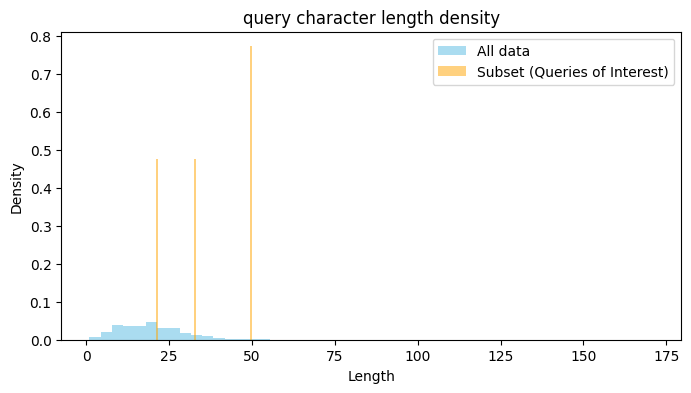

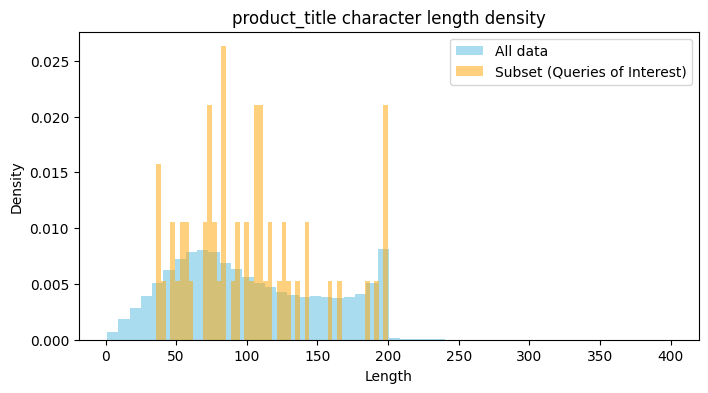

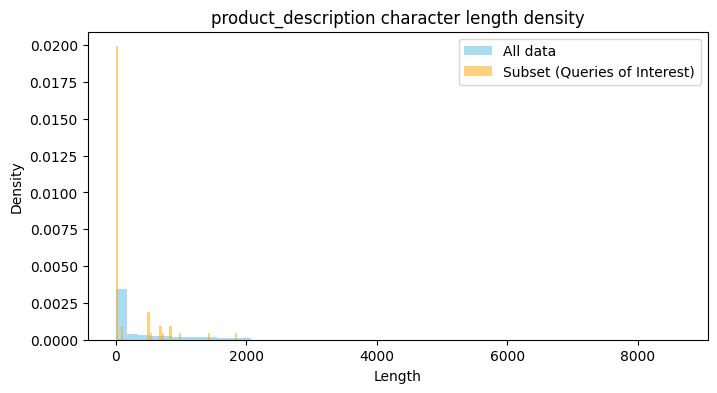

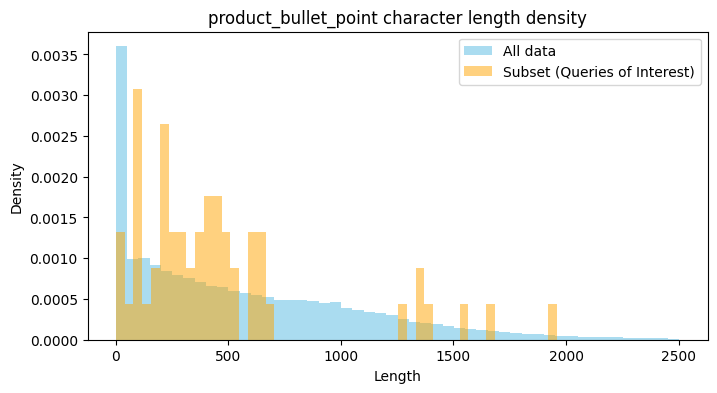

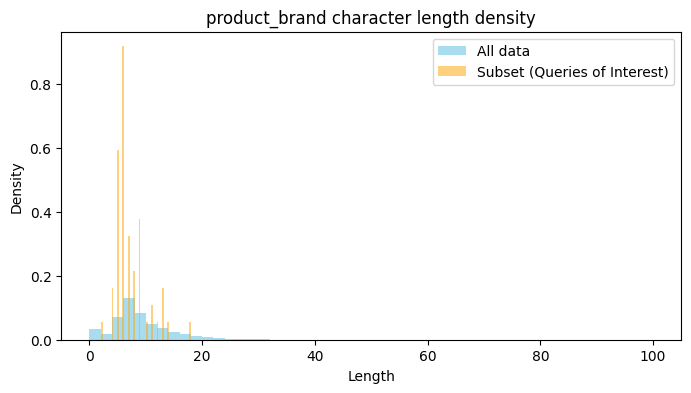

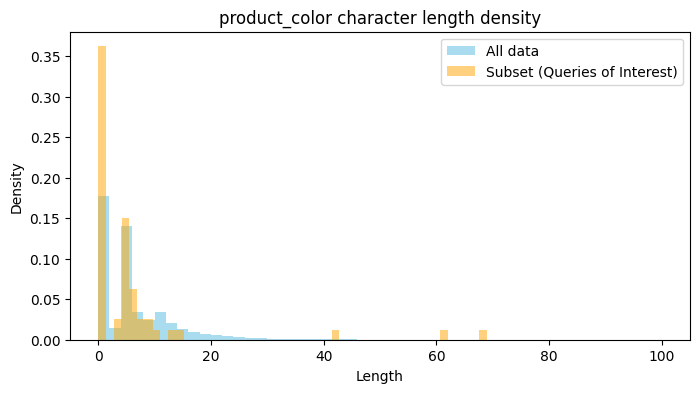

In [51]:
# Plot kernel density histograms for full dataset and subset on same axis
# densities avoid scale issues when subset is much smaller
queries_of_interest = [
    "aa batteries 100 pack",
    "kodak photo paper 8.5 x 11 glossy",
    "dewalt 8v max cordless screwdriver kit, gyroscopic"
]

subset = df[df["query"].isin(queries_of_interest)].copy()

for c in cols_of_interest:
    plt.figure(figsize=(8,4))
    # full data density
    plt.hist(char_lengths[c], bins=50, density=True, color='skyblue', alpha=0.7, label='All data')
    # subset density
    if c in subset.columns:
        subset_lengths = subset[c].fillna('').astype(str).apply(len)
        plt.hist(subset_lengths, bins=50, density=True, color='orange', alpha=0.5, label='Subset (Queries of Interest)')
    plt.title(f'{c} character length density')
    plt.xlabel('Length')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

In [ ]:
df[""]

In [54]:
print(f"Average full product context length: {df['full_product_context_length'].mean()}")
print(f"Maximum full product context length: {df['full_product_context_length'].max()}")
print(f"Minimum full product context length: {df['full_product_context_length'].min()}")

Average full product context length: 1074.1661236766047
Maximum full product context length: 8796
Minimum full product context length: 1


In [53]:
print(f"Average full product context length: {subset[subset['esci_label']=='E']['full_product_context_length'].mean()}")
print(f"Maximum full product context length: {subset[subset['esci_label']=='E']['full_product_context_length'].max()}")
print(f"Minimum full product context length: {subset[subset['esci_label']=='E']['full_product_context_length'].min()}")

Average full product context length: 671.25
Maximum full product context length: 3726
Minimum full product context length: 81


In [57]:
print(subset[subset['esci_label']=='E'].loc[660827]["full_product_context"])

ENERTWIST Cordless Screwdriver, 8V Max 10Nm Electric Screwdriver Rechargeable Set with 82 Accessory Kit and Charger in Carrying Case, 21+1 Cluth, Dual Position Handle, LED Light, ET-CS-8 【Powerful 8V Motor & Max 10Nm Torque】Enertwist cordless screwdriver equiped with higher performance 8V motor, delivers improved 88 in.lbs(10Nm) max torque for a wide range of drilling and fastening applications. Manual mode torque 10Nm max.
【Precision 21+1 Cluth & 230RPM Speed】21 clutch + 1 drill setting for precision and control based on the application. No load speed 230 RPM for fastening/drilling into wood, plastic & light-gauge metal.
【Convenient 1/4" Hex Chuck and Durable Use】¼ inch hex allows for quick screwdriver bit change and holds 1 inch bit tips. Cordless electric screwdriver battery powered by 1500mAh built-in lithium-ion battery for long lasting use. Screw 300pcs M4*40mm in specification continuously after fully charged. (When most other specified < M3.5 only)
【Ergonomic 2-Position Handle 

In [ ]:
# Load the results.csv and convert to markdown table
results = pd.read_csv("/Users/aaronallen/Desktop/grainger_project/results.csv")